In [1]:
!pip install nbformat

# Effect of outliers on ML Algorithms

| Algorithm | Sensitivity | Reason |
|---|---|---|
| Linear Regression | 🔴 Very High | Least squares magnifies outliers |
| Logistic Regression | 🔴 High | Decision boundary shifts |
| SVM | 🔴 Very High | Support vectors change |
| KNN | 🔴 High | Distance-based |
| K-Means | 🔴 Very High | Centroid shifts |
| Decision Tree | 🟡 Moderate | Extra splits created |
| Gradient Boosting | 🟡 Moderate | Focuses on errors |
| Neural Networks | 🟡 Moderate | Depends on data size |
| Ridge/Lasso | 🟡 Moderate | Regularization helps |
| Random Forest | 🟢 Low | Averaging effect |
| Naive Bayes | 🟢 Low | Probability-based |

##effect of outliear
* Change the mean (average)
* Increase variance & standard deviation
* Distort graphs
* Affect machine learning models
* Reduce prediction accuracy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('tips')

In [3]:
df.shape

(244, 7)

In [4]:
df.sample(5)

,total_bill,tip,sex,smoker,day,time,size
132,11.17,1.50,Female,No,Thur,Lunch,2
79,17.29,2.71,Male,No,Thur,Lunch,2
185,20.69,5.00,Male,No,Sun,Dinner,5
94,22.75,3.25,Female,No,Fri,Dinner,2
84,15.98,2.03,Male,No,Thur,Lunch,2


/tmp/ipython-input-2266194707.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['total_bill'])
/tmp/ipython-input-2266194707.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['tip'])


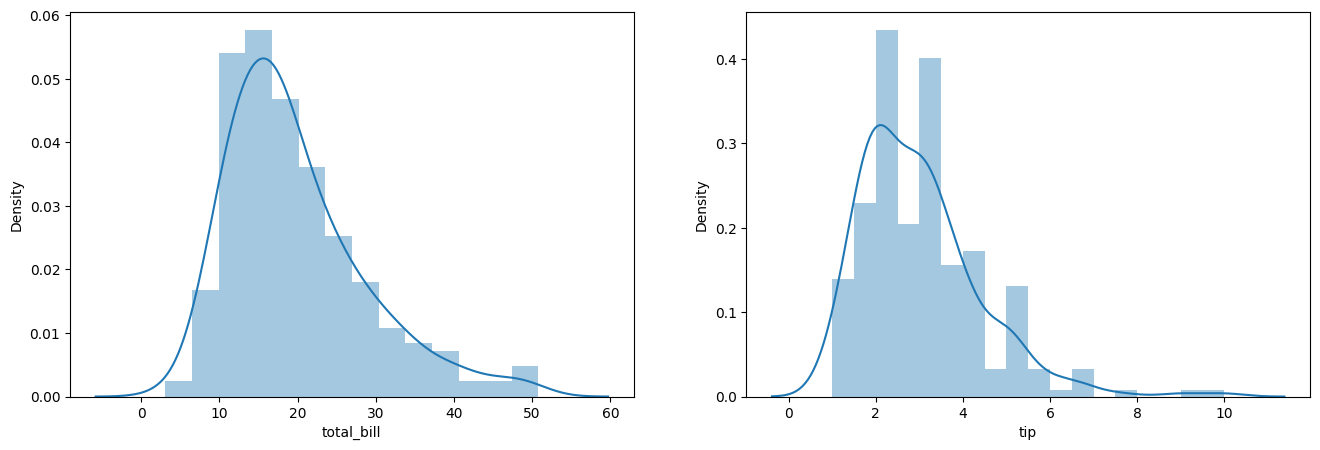

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['total_bill'])
plt.subplot(1,2,2)
sns.distplot(df['tip'])
plt.show()

In [6]:
df['total_bill'].skew()

np.float64(1.1332130376158205)

In [7]:
print("Mean value of total_bill", df['total_bill'].mean())
print("Std value of total_bill",  df['total_bill'].std())
print("Min value of total_bill",  df['total_bill'].min())
print("Max value of total_bill",  df['total_bill'].max())

Mean value of total_bill 19.78594262295082
Std value of total_bill 8.902411954856856
Min value of total_bill 3.07
Max value of total_bill 50.81


In [8]:
print("Highest allowed", df['total_bill'].mean() + 3*df['total_bill'].std())
print("Lowest allowed",  df['total_bill'].mean() - 3*df['total_bill'].std())

Highest allowed 46.49317848752139
Lowest allowed -6.921293241619747


In [9]:
upper = df['total_bill'].mean() + 3*df['total_bill'].std()
lower = df['total_bill'].mean() - 3*df['total_bill'].std()

df[(df['total_bill'] > upper) | (df['total_bill'] < lower)]

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4


##Trimming (Boundary Values)

In [10]:
new_df = df[(df['total_bill'] < upper) & (df['total_bill'] > lower)]
new_df.shape

(240, 7)

In [11]:
df['total_bill_zscore'] = (df['total_bill'] - df['total_bill'].mean()) / df['total_bill'].std()
df.head()

,total_bill,tip,sex,smoker,day,time,size,total_bill_zscore
0,16.99,1.01,Female,No,Sun,Dinner,2,-0.314066
1,10.34,1.66,Male,No,Sun,Dinner,3,-1.061054
2,21.01,3.50,Male,No,Sun,Dinner,3,0.137497
3,23.68,3.31,Male,No,Sun,Dinner,2,0.437416
4,24.59,3.61,Female,No,Sun,Dinner,4,0.539635


In [13]:
df[(df['total_bill_zscore'] > 3) | (df['total_bill_zscore'] < -3)]



,total_bill,tip,sex,smoker,day,time,size,total_bill_zscore
59,48.27,6.73,Male,No,Sat,Dinner,4,3.199589
156,48.17,5.00,Male,No,Sun,Dinner,6,3.188356
170,50.81,10.00,Male,Yes,Sat,Dinner,3,3.484905
212,48.33,9.00,Male,No,Sat,Dinner,4,3.206329


In [14]:
new_df = df[(df['total_bill_zscore'] < 3) & (df['total_bill_zscore'] > -3)]
new_df.shape

(240, 8)

##Capping

In [15]:
upper_limit = df['total_bill'].mean() + 3*df['total_bill'].std()
lower_limit = df['total_bill'].mean() - 3*df['total_bill'].std()

print("Upper Limit:", upper_limit)
print("Lower Limit:", lower_limit)

Upper Limit: 46.49317848752139
Lower Limit: -6.921293241619747


In [16]:
df['total_bill'] = np.where(
    df['total_bill'] > upper_limit,
    upper_limit,
    np.where(
        df['total_bill'] < lower_limit,
        lower_limit,
        df['total_bill']
    )
)


In [17]:
df['total_bill'].describe()


,total_bill
count,244.000000
mean,19.746568
std,8.776357
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,46.493178
